In [1]:
# ===============================
# Kütüphanelerin Yüklenmesi
# ===============================

import os
import random
import shutil
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from PIL import Image
import IPython.display as ipd

warnings.filterwarnings("ignore", category=UserWarning, module="keras")

In [3]:
# ===============================
# Veri Yolu Tanımlama ve Klasör Kontrolü
# ===============================

DATA_DIR = r"C:\Users\BN\Downloads\derinogrenme"

YES_DIR = os.path.join(DATA_DIR, "yes")
NO_DIR  = os.path.join(DATA_DIR, "no")

print(f"YES klasörü: {YES_DIR} -> {len(os.listdir(YES_DIR))} görüntü")
print(f"NO  klasörü: {NO_DIR}  -> {len(os.listdir(NO_DIR))} görüntü")

YES klasörü: C:\Users\BN\Downloads\derinogrenme\yes -> 1500 görüntü
NO  klasörü: C:\Users\BN\Downloads\derinogrenme\no  -> 1500 görüntü


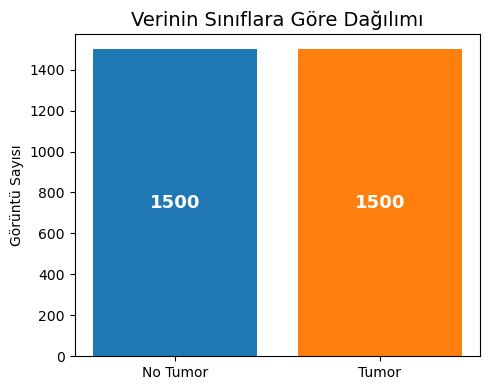

In [5]:
# ===============================
# Verinin Sınıflara Göre Dağılımı
# ===============================

yes_count = len(os.listdir(YES_DIR))
no_count  = len(os.listdir(NO_DIR))

plt.figure(figsize=(5, 4))

colors = ["#1f77b4", "#ff7f0e"]

bars = plt.bar(
    ["No Tumor", "Tumor"],
    [no_count, yes_count],
    color=colors
)

plt.title("Verinin Sınıflara Göre Dağılımı", fontsize=14)
plt.ylabel("Görüntü Sayısı")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"{int(height)}",
        ha="center",
        va="center",
        fontsize=13,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

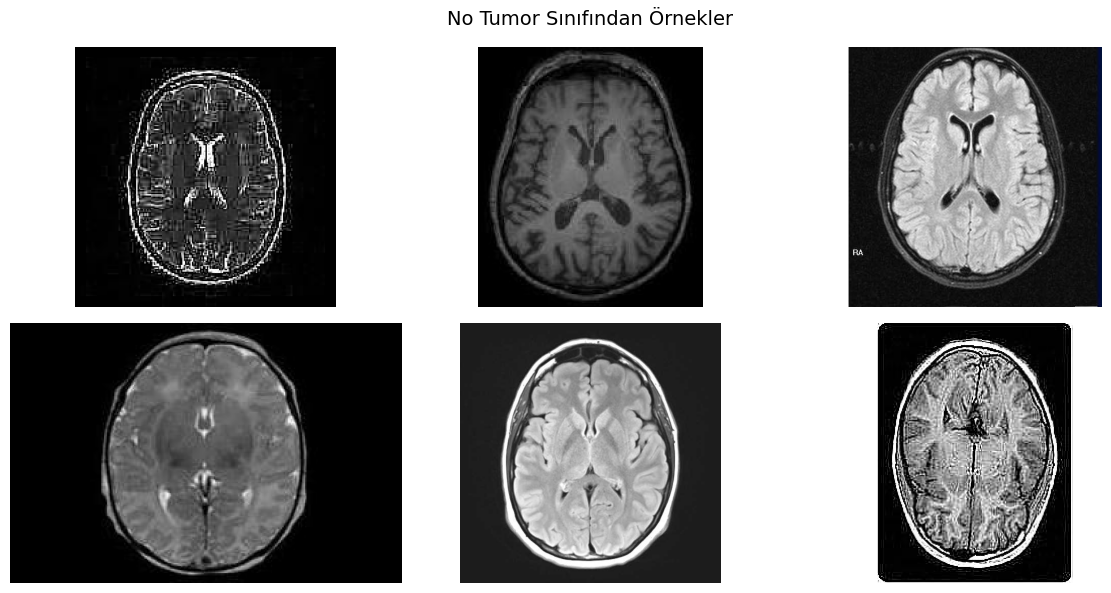

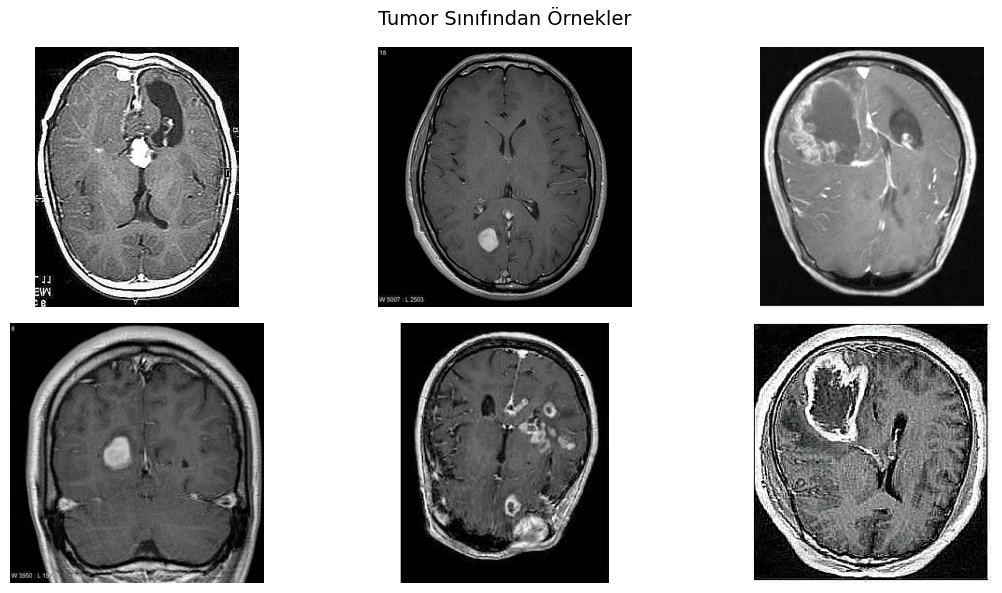

In [7]:
# ===============================
# Rastgele Görüntü Örnekleri
# ===============================

def show_random_images(folder, title, n=6):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    samples = random.sample(files, min(n, len(files)))

    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 3 * rows))

    for i, fname in enumerate(samples):
        img_path = os.path.join(folder, fname)
        img = Image.open(img_path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_random_images(NO_DIR,  "No Tumor Sınıfından Örnekler")
show_random_images(YES_DIR, "Tumor Sınıfından Örnekler")

In [8]:
# ===============================
# Train / Validation / Test Bölme
# ===============================

BASE_SPLIT_DIR = os.path.join(DATA_DIR, "split_data")
train_dir = os.path.join(BASE_SPLIT_DIR, "train")
val_dir   = os.path.join(BASE_SPLIT_DIR, "val")
test_dir  = os.path.join(BASE_SPLIT_DIR, "test")

# Klasörleri oluştur
for d in [train_dir, val_dir, test_dir]:
    for cls in ["yes", "no"]:
        os.makedirs(os.path.join(d, cls), exist_ok=True)

# Dosya listeleri
yes_files = [
    os.path.join(YES_DIR, f)
    for f in os.listdir(YES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

no_files = [
    os.path.join(NO_DIR, f)
    for f in os.listdir(NO_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Toplam YES:", len(yes_files))
print("Toplam NO :", len(no_files))

# %70 Train, %15 Validation, %15 Test
yes_train, yes_temp = train_test_split(yes_files, test_size=0.30, random_state=42)
yes_val,   yes_test = train_test_split(yes_temp,  test_size=0.50, random_state=42)

no_train, no_temp = train_test_split(no_files, test_size=0.30, random_state=42)
no_val,   no_test = train_test_split(no_temp,  test_size=0.50, random_state=42)

def copy_files(file_list, target_folder):
    for src in file_list:
        dst = os.path.join(target_folder, os.path.basename(src))
        shutil.copy(src, dst)

# Kopyalama
copy_files(yes_train, os.path.join(train_dir, "yes"))
copy_files(yes_val,   os.path.join(val_dir,   "yes"))
copy_files(yes_test,  os.path.join(test_dir,  "yes"))

copy_files(no_train,  os.path.join(train_dir, "no"))
copy_files(no_val,    os.path.join(val_dir,   "no"))
copy_files(no_test,   os.path.join(test_dir,  "no"))

def count_split(base_dir):
    return (
        len(os.listdir(os.path.join(base_dir, "no"))),
        len(os.listdir(os.path.join(base_dir, "yes")))
    )

train_no, train_yes = count_split(train_dir)
val_no,   val_yes   = count_split(val_dir)
test_no,  test_yes  = count_split(test_dir)

print(f"Train -> no: {train_no}, yes: {train_yes}")
print(f"Val   -> no: {val_no},   yes: {val_yes}")
print(f"Test  -> no: {test_no},  yes: {test_yes}")

Toplam YES: 1500
Toplam NO : 1500
Train -> no: 1050, yes: 1050
Val   -> no: 225,   yes: 225
Test  -> no: 225,  yes: 225


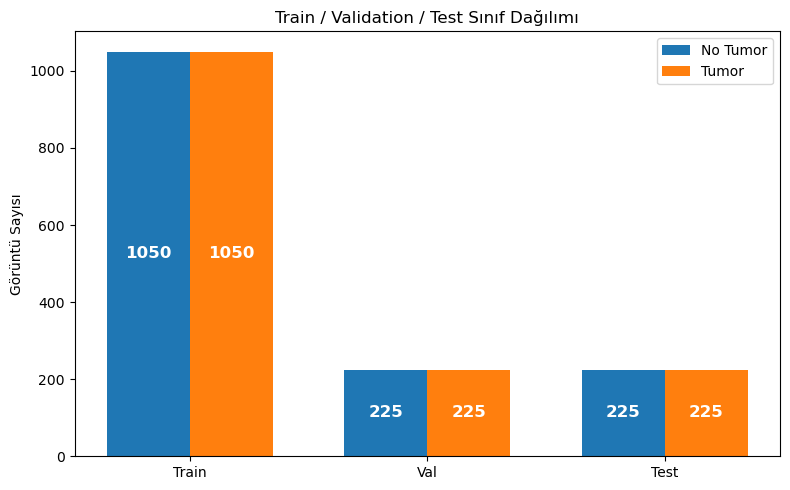

In [9]:
# ===============================
# Train / Validation / Test Sınıf Dağılımı
# ===============================

labels = ["Train", "Val", "Test"]
no_vals  = [train_no, val_no, test_no]
yes_vals = [train_yes, val_yes, test_yes]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

bars_no = plt.bar(
    x - width / 2, no_vals, width,
    label="No Tumor", color="#1f77b4"
)

bars_yes = plt.bar(
    x + width / 2, yes_vals, width,
    label="Tumor", color="#ff7f0e"
)

plt.xticks(x, labels)
plt.ylabel("Görüntü Sayısı")
plt.title("Train / Validation / Test Sınıf Dağılımı")
plt.legend()

for bars in [bars_no, bars_yes]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f"{int(height)}",
            ha="center",
            va="center",
            color="white",
            fontsize=12,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [10]:
# ===============================
# ImageDataGenerator ile Ön İşleme ve Veri Artırma
# ===============================

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Sınıf indeksleri:", train_gen.class_indices)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Sınıf indeksleri: {'no': 0, 'yes': 1}


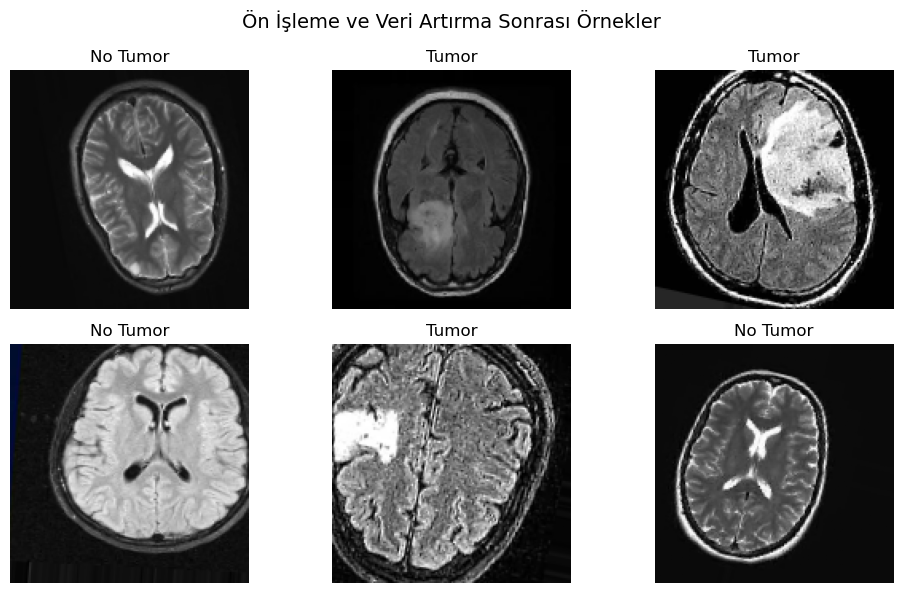

In [11]:
# ===============================
# Veri Artırma Sonrası Örnek Görüntüler
# ===============================

images, labels = next(train_gen)

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("Tumor" if labels[i] == 1 else "No Tumor")

plt.suptitle("Ön İşleme ve Veri Artırma Sonrası Örnekler", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# ===============================
# Scratch CNN Modeli (Functional API – Base + Head)
# ===============================

from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input")

# -------- BASE (Feature Extractor) --------
x = Conv2D(32, (3, 3), activation="relu", padding="same", name="base_conv1")(inputs)
x = MaxPooling2D(2, 2, name="pool1")(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same", name="base_conv2")(x)
x = MaxPooling2D(2, 2, name="pool2")(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same", name="base_conv3")(x)
x = MaxPooling2D(2, 2, name="pool3")(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same", name="last_conv")(x)
x = MaxPooling2D(2, 2, name="pool4")(x)

# -------- HEAD (Classifier – TL ile AYNI olacak şekilde) --------
x = GlobalAveragePooling2D(name="head_gap")(x)
x = Dense(512, activation="relu", name="head_dense")(x)   
x = Dropout(0.5, name="head_dropout")(x)
outputs = Dense(1, activation="sigmoid", name="head_out")(x)

# Model
model = Model(inputs=inputs, outputs=outputs, name="ScratchCNN_Functional")

# Compile
model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "ScratchCNN_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ base_conv1 (Conv2D)                  │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ base_conv2 (Conv2D)                  │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ base_conv3 (Conv2D)                  │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ last_conv (Conv2D)                   │ (None, 18, 18, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool4 (MaxPooling2D)                 │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_gap (GlobalAveragePooling2D)    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dense (Dense)                   │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout (Dropout)               │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_out (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 307,393 (1.17 MB)

 Trainable params: 307,393 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

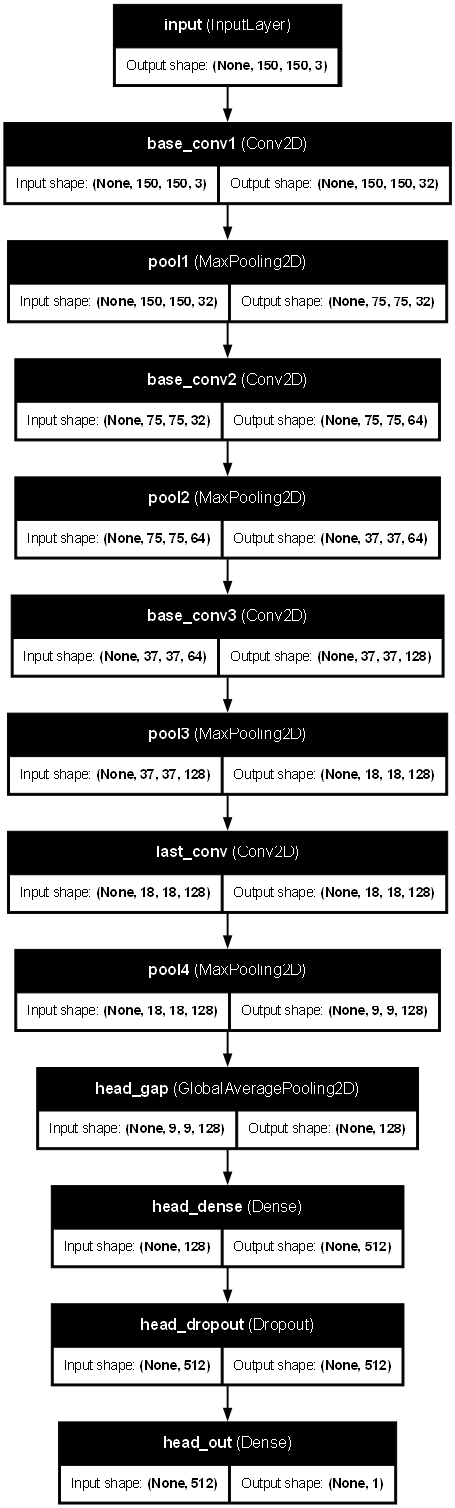

In [19]:
# ===============================
# CNN Mimarisinin Görselleştirilmesi
# ===============================

plot_model(
    model,
    to_file="cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)

ipd.display(ipd.Image(filename="cnn_architecture.png"))


In [21]:
# ===============================
# Scratch CNN Modelinin Eğitimi
# ===============================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 20

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="best_cnn_br35h.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("Model başarıyla kaydedildi: best_cnn_br35h.keras")


Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 486ms/step - accuracy: 0.4973 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.6825
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 315ms/step - accuracy: 0.5478 - loss: 0.6798 - val_accuracy: 0.5933 - val_loss: 0.6598
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 324ms/step - accuracy: 0.6100 - loss: 0.6610 - val_accuracy: 0.6911 - val_loss: 0.6239
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 336ms/step - accuracy: 0.5973 - loss: 0.6612 - val_accuracy: 0.7067 - val_loss: 0.6083
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.6842 - loss: 0.6114 - val_accuracy: 0.7178 - val_loss: 0.5760
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 328ms/step - accuracy: 0.6883 - loss: 0.6029 - val_accuracy: 0.7133 - val_loss: 0.5675
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 326ms/step - accuracy: 0.6572 - loss: 0.6089 - val_accuracy: 0.7044 - val_loss: 0.5717
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 325ms/step - accuracy: 0.6773 - loss: 0.5878 - val_accu

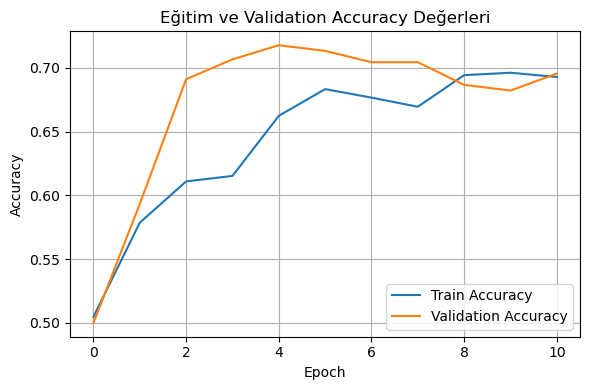

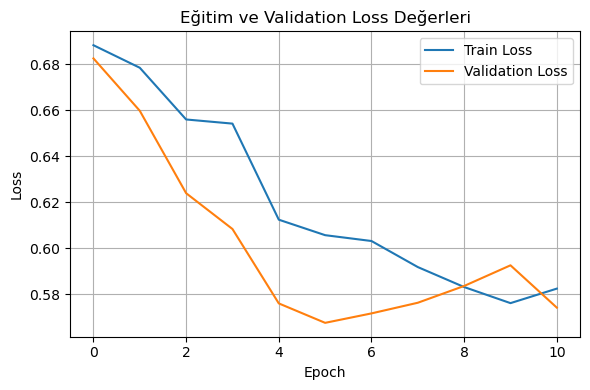

In [23]:
# ===============================
# Accuracy ve Loss Grafiklerinin Çizdirilmesi
# ===============================

# Accuracy Grafiği
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Eğitim ve Validation Accuracy Değerleri")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss Grafiği
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Eğitim ve Validation Loss Değerleri")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# ===============================
# Test Seti Üzerinde Model Değerlendirmesi
# ===============================

test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.7579 - loss: 0.5322
Test Loss : 0.5430
Test Accuracy : 0.7556


In [27]:
# ===============================
# Grad-CAM Fonksiyonları (Scratch CNN)
# ===============================

import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_channel = preds[:, 0]  # binary sigmoid

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap_on_image(img, heatmap, alpha=0.35):
    """
    img: (H,W,3) 0..1 veya 0..255
    heatmap: (h,w) 0..1
    """
    if img.max() <= 1.0:
        base = (img * 255).astype("uint8")
    else:
        base = img.astype("uint8")

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (base.shape[0], base.shape[1])
    ).numpy().squeeze()

    return base, heatmap_resized

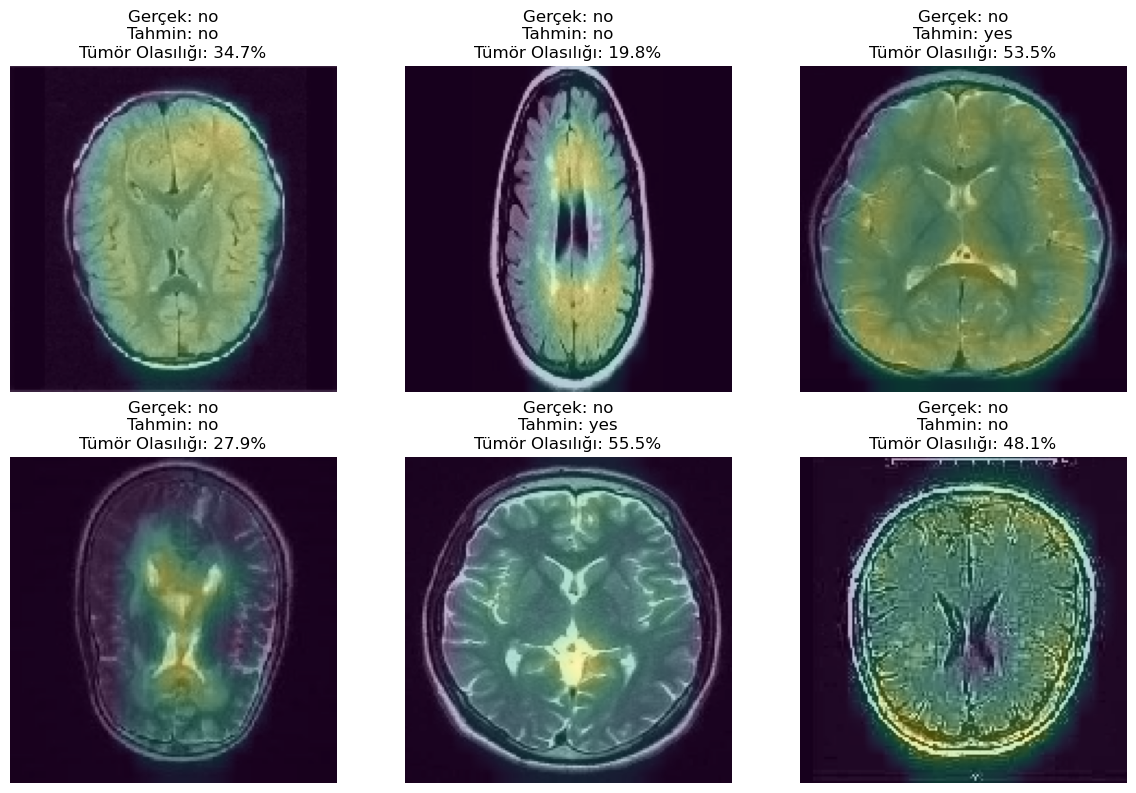

In [29]:
# ===============================
# Testten Rastgele 6 Örnek + Grad-CAM
# ===============================

x_batch, y_batch = next(test_gen)

idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

n_samples = 6
indices = np.random.choice(len(x_batch), n_samples, replace=False)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = x_batch[idx]
    true_label = int(y_batch[idx]) if np.ndim(y_batch[idx]) == 0 else int(y_batch[idx][0])

    # Tahmin
    img_array = img[None, ...].astype("float32")
    prob = float(model.predict(img_array, verbose=0).ravel()[0])
    pred_label = 1 if prob >= 0.5 else 0

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv")
    base, heatmap_resized = overlay_heatmap_on_image(img, heatmap, alpha=0.35)

    # Plot
    plt.subplot(2, 3, i + 1)
    plt.imshow(base)
    plt.imshow(heatmap_resized, alpha=0.35)
    plt.axis("off")

    plt.title(
        f"Gerçek: {idx_to_class[true_label]}\n"
        f"Tahmin: {idx_to_class[pred_label]}\n"
        f"Tümör Olasılığı: {prob*100:.1f}%"
    )

plt.tight_layout()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step


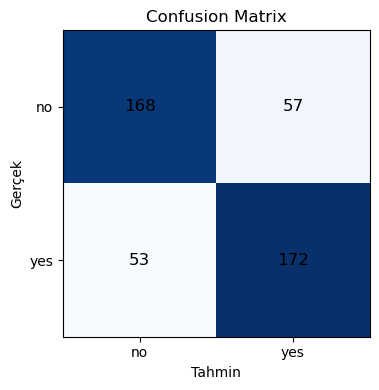

Classification Report:
              precision    recall  f1-score   support

          no       0.76      0.75      0.75       225
         yes       0.75      0.76      0.76       225

    accuracy                           0.76       450
   macro avg       0.76      0.76      0.76       450
weighted avg       0.76      0.76      0.76       450



In [31]:
# ===============================
# Confusion Matrix ve Classification Report
# ===============================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Tahminler
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Gerçek etiketler
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="black", fontsize=12
        )

plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [33]:
# ===============================
# 3 Model Karşılaştırma + Grad-CAM
# Scratch CNN vs ResNet50 TL vs DenseNet121 TL
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [35]:
# ------------------------------------------------------------
# Model summary'leri düzenli gösterme fonksiyonu
# ------------------------------------------------------------
def show_model_summary(model, title):
    print("\n" + "="*70)
    print(title)
    print("="*70)
    model.summary()

In [37]:
# ------------------------------------------------------------
# 1) Scratch CNN modelini yükle
# ------------------------------------------------------------
scratch_model = tf.keras.models.load_model("best_cnn_br35h.keras")
print("Scratch CNN yüklendi:", scratch_model.name)
show_model_summary(scratch_model, "Model 1: Scratch CNN")

Scratch CNN yüklendi: ScratchCNN_Functional

Model 1: Scratch CNN


Model: "ScratchCNN_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ base_conv1 (Conv2D)                  │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ base_conv2 (Conv2D)                  │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ base_conv3 (Conv2D)                  │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ last_conv (Conv2D)                   │ (None, 18, 18, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool4 (MaxPooling2D)                 │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_gap (GlobalAveragePooling2D)    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dense (Dense)                   │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout (Dropout)               │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_out (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 922,181 (3.52 MB)

 Trainable params: 307,393 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 614,788 (2.35 MB)

In [39]:
# ------------------------------------------------------------
# 2) Scratch için generator (rescale=1./255)
# ------------------------------------------------------------
scratch_datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
scratch_datagen_eval = ImageDataGenerator(rescale=1./255)

train_gen_scratch = scratch_datagen_train.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED
)
val_gen_scratch = scratch_datagen_eval.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED
)
test_gen_scratch = scratch_datagen_eval.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.


In [41]:
# ------------------------------------------------------------
# 3) TL generator (preprocess_input'a göre)
# ------------------------------------------------------------
def make_tl_generators(preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True
    )
    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary", seed=SEED
    )
    val_gen = eval_datagen.flow_from_directory(
        val_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary", seed=SEED
    )
    test_gen = eval_datagen.flow_from_directory(
        test_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
    )
    return train_gen, val_gen, test_gen

In [43]:
# ------------------------------------------------------------
# 4) Ortak head
# ------------------------------------------------------------
def build_shared_head(x, dense_units=512, dropout=0.5):
    x = GlobalAveragePooling2D(name="head_gap")(x)
    x = Dense(dense_units, activation="relu", name="head_dense")(x)
    x = Dropout(dropout, name="head_dropout")(x)
    out = Dense(1, activation="sigmoid", name="head_out")(x)
    return out

In [45]:
# ------------------------------------------------------------
# 5) TL model kur (ResNet50 / DenseNet121)
#   -> İç backbone modeline isim veriyoruz ki Grad-CAM kolay olsun
# ------------------------------------------------------------
def build_tl_model(backbone="resnet50", dense_units=512, dropout=0.5):
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name=f"{backbone}_input")

    if backbone == "resnet50":
        base = tf.keras.applications.ResNet50(
            include_top=False, weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        base._name = "resnet50_backbone"   # <-- kritik: sabit isim
        preprocess_fn = tf.keras.applications.resnet50.preprocess_input

    elif backbone == "densenet121":
        base = tf.keras.applications.DenseNet121(
            include_top=False, weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        base._name = "densenet121_backbone"  # <-- kritik: sabit isim
        preprocess_fn = tf.keras.applications.densenet.preprocess_input

    else:
        raise ValueError("backbone 'resnet50' veya 'densenet121' olmalı.")

    base.trainable = False
    x = base(inputs, training=False)
    outputs = build_shared_head(x, dense_units=dense_units, dropout=dropout)

    model = Model(inputs, outputs, name=f"{backbone.upper()}_TL")
    model.compile(
        optimizer=Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model, preprocess_fn

In [47]:
# ------------------------------------------------------------
# 6) Callbacks
# ------------------------------------------------------------
def make_callbacks(save_path):
    return [
        ModelCheckpoint(save_path, monitor="val_loss", save_best_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
    ]

In [49]:
# ------------------------------------------------------------
# 7) SKLEARN metrikleri
# ------------------------------------------------------------
def eval_metrics(model, test_gen, threshold=0.5):
    y_prob = model.predict(test_gen, verbose=1).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    y_true = test_gen.classes

    return {
        "accuracy": float((y_pred == y_true).mean()),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [51]:
# ------------------------------------------------------------
# 8) Confusion Matrix plot
# ------------------------------------------------------------
def plot_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xticks([0, 1], class_names)
    plt.yticks([0, 1], class_names)
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12, color="black")

    plt.tight_layout()
    plt.show()

In [53]:
# ------------------------------------------------------------
# 9) 3 modeli tek grafikte metrik karşılaştırma
# ------------------------------------------------------------
def plot_metrics_bar(results):
    metrics = ["accuracy", "precision", "recall", "f1", "auc"]
    model_names = list(results.keys())

    values = np.array([[results[m][k] for k in metrics] for m in model_names])

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(10, 5))
    for i, name in enumerate(model_names):
        plt.bar(x + (i - 1) * width, values[i], width, label=name)

    plt.xticks(x, metrics)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Scratch CNN vs ResNet50 vs DenseNet121 - Test Metrikleri")
    plt.legend()
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

In [55]:
# ------------------------------------------------------------
# 10) Grad-CAM (Scratch + TL)
# ------------------------------------------------------------
def find_last_conv_layer(model):
    """Model içinde (dış modelde) en sondaki conv benzeri (4D output) layer adını döndürür."""
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except:
            pass
    return None

def find_backbone_model(model):
    """Dış modelin içinde gömülü backbone modelini yakala (ResNet/DenseNet)."""
    # önce bizim sabit isimler
    for name in ["resnet50_backbone", "densenet121_backbone"]:
        try:
            return model.get_layer(name)
        except:
            pass

    # bulamazsa: Model olan ilk katmanı yakala
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer

    return None

def make_gradcam_heatmap(img_array, model, last_conv_layer_name,
                         backbone_layer_name=None):
    """
    - backbone_layer_name None ise: last_conv_layer_name dış modelde aranır (Scratch gibi)
    - backbone_layer_name verilirse: last_conv_layer_name backbone içinde aranır (TL gibi)
    """
    if backbone_layer_name is None:
        # Scratch gibi
        conv_layer = model.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[conv_layer.output, model.output]
        )
    else:
        # TL gibi: backbone içinden layer al
        backbone = model.get_layer(backbone_layer_name)
        conv_layer = backbone.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[conv_layer.output, model.output]
        )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.35):
    if img.max() <= 1.0:
        base = (img * 255).astype("uint8")
    else:
        base = img.astype("uint8")

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (base.shape[0], base.shape[1])
    ).numpy().squeeze()

    return base, heatmap_resized

def show_gradcam_samples(model, test_gen, title_prefix,
                         last_conv_layer_name=None,
                         backbone_layer_name=None,
                         n_samples=6):
    # layer adı verilmezse otomatik bul
    if backbone_layer_name is None:
        # dış modelden ara
        if last_conv_layer_name is None:
            last_conv_layer_name = find_last_conv_layer(model)
    else:
        # backbone içinden ara
        backbone = model.get_layer(backbone_layer_name)
        if last_conv_layer_name is None:
            last_conv_layer_name = find_last_conv_layer(backbone)

    if last_conv_layer_name is None:
        raise ValueError(f"{title_prefix}: conv layer bulunamadı.")

    x_batch, y_batch = next(test_gen)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    indices = np.random.choice(len(x_batch), min(n_samples, len(x_batch)), replace=False)

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(indices):
        img = x_batch[idx]
        true_label = int(y_batch[idx]) if np.ndim(y_batch[idx]) == 0 else int(y_batch[idx][0])

        img_array = img[None, ...].astype("float32")
        prob = float(model.predict(img_array, verbose=0).ravel()[0])
        pred_label = 1 if prob >= 0.5 else 0

        heatmap = make_gradcam_heatmap(
            img_array, model,
            last_conv_layer_name=last_conv_layer_name,
            backbone_layer_name=backbone_layer_name
        )
        base, heatmap_resized = overlay_heatmap(img, heatmap, alpha=0.35)

        plt.subplot(2, 3, i + 1)
        plt.imshow(base)
        plt.imshow(heatmap_resized, alpha=0.35)
        plt.axis("off")
        plt.title(
            f"{title_prefix}\nGerçek: {idx_to_class[true_label]}\n"
            f"Tahmin: {idx_to_class[pred_label]} | {prob*100:.1f}%"
        )

    plt.tight_layout()
    plt.show()

In [57]:
# ------------------------------------------------------------
# 11) ResNet50 TL: kur + summary + eğit + değerlendir
# ------------------------------------------------------------
resnet_model, res_preprocess = build_tl_model("resnet50", dense_units=512, dropout=0.5)
show_model_summary(resnet_model, "Model 2: ResNet50 Transfer Learning")

train_gen_res, val_gen_res, test_gen_res = make_tl_generators(res_preprocess)

history_res = resnet_model.fit(
    train_gen_res,
    epochs=20,
    validation_data=val_gen_res,
    callbacks=make_callbacks("best_resnet50_tl.keras"),
    verbose=1
)


Model 2: ResNet50 Transfer Learning


Model: "RESNET50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50_input (InputLayer)          │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 5, 5, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_gap (GlobalAveragePooling2D)    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dense (Dense)                   │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout (Dropout)               │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_out (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.6474 - loss: 0.7092
Epoch 1: val_loss improved from inf to 0.27414, saving model to best_resnet50_tl.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 697ms/step - accuracy: 0.6490 - loss: 0.7065 - val_accuracy: 0.8822 - val_loss: 0.2741 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8684 - loss: 0.3158
Epoch 2: val_loss improved from 0.27414 to 0.23787, saving model to best_resnet50_tl.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 699ms/step - accuracy: 0.8685 - loss: 0.3157 - val_accuracy: 0.9178 - val_loss: 0.2379 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9038 - loss: 0.2504
Epoch 3: val_loss improved from 0.23787 to 0.21643, saving model to best_resnet50_tl.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 728ms/step - accuracy: 0.9

In [59]:
# ------------------------------------------------------------
# 12) DenseNet121 TL: kur + summary + eğit + değerlendir
# ------------------------------------------------------------
densenet_model, dn_preprocess = build_tl_model("densenet121", dense_units=512, dropout=0.5)
show_model_summary(densenet_model, "Model 3: DenseNet121 Transfer Learning")

train_gen_dn, val_gen_dn, test_gen_dn = make_tl_generators(dn_preprocess)

history_dn = densenet_model.fit(
    train_gen_dn,
    epochs=20,
    validation_data=val_gen_dn,
    callbacks=make_callbacks("best_densenet121_tl.keras"),
    verbose=1
)


Model 3: DenseNet121 Transfer Learning


Model: "DENSENET121_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121_input (InputLayer)       │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ densenet121 (Functional)             │ (None, 4, 4, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_gap (GlobalAveragePooling2D)    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dense (Dense)                   │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout (Dropout)               │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_out (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,562,817 (28.85 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.6147 - loss: 0.8112
Epoch 1: val_loss improved from inf to 0.38149, saving model to best_densenet121_tl.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 772ms/step - accuracy: 0.6159 - loss: 0.8087 - val_accuracy: 0.8422 - val_loss: 0.3815 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7952 - loss: 0.4503
Epoch 2: val_loss improved from 0.38149 to 0.29270, saving model to best_densenet121_tl.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 744ms/step - accuracy: 0.7956 - loss: 0.4495 - val_accuracy: 0.8778 - val_loss: 0.2927 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8501 - loss: 0.3612
Epoch 3: val_loss improved from 0.29270 to 0.26900, saving model to best_densenet121_tl.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 749ms/step - accu

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 577ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 699ms/step

--- TEST METRİKLERİ ---

Scratch CNN
  accuracy: 0.7556
  precision: 0.7511
  recall: 0.7644
  f1: 0.7577
  auc: 0.8337

ResNet50 TL
  accuracy: 0.9356
  precision: 0.8920
  recall: 0.9911
  f1: 0.9389
  auc: 0.9924

DenseNet121 TL
  accuracy: 0.9689
  precision: 0.9689
  recall: 0.9689
  f1: 0.9689
  auc: 0.9947

Scratch CNN Classification Report:
              precision    recall  f1-score   support

          no       0.76      0.75      0.75       225
         yes       0.75      0.76      0.76       225

    accuracy                           0.76       450
   macro avg       0.76      0.76      0.76       450
weighted avg       0.76      0.76      0.76       450



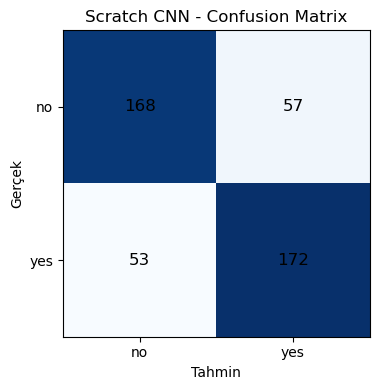


ResNet50 TL Classification Report:
              precision    recall  f1-score   support

          no       0.99      0.88      0.93       225
         yes       0.89      0.99      0.94       225

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450



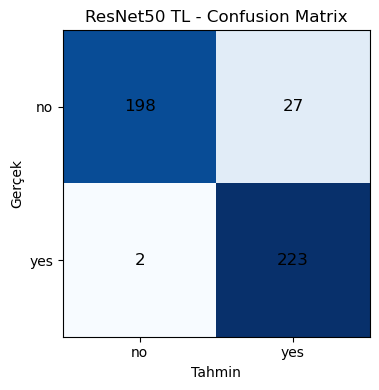


DenseNet121 TL Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.97      0.97       225
         yes       0.97      0.97      0.97       225

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



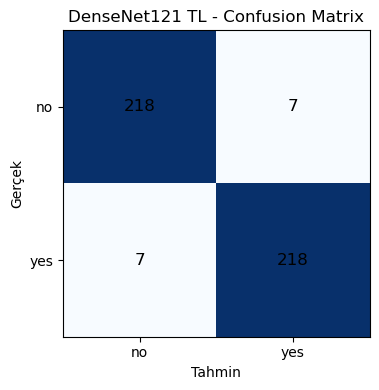

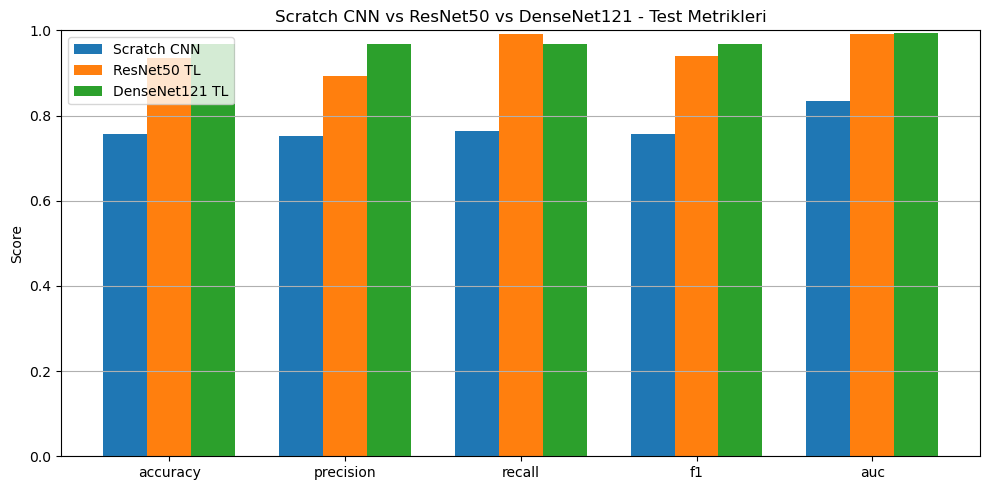

In [61]:
# ------------------------------------------------------------
# 13) 3 Model: Test metrikleri + CM + Report
# ------------------------------------------------------------
scratch_metrics = eval_metrics(scratch_model, test_gen_scratch)
res_metrics     = eval_metrics(resnet_model, test_gen_res)
dn_metrics      = eval_metrics(densenet_model, test_gen_dn)

results = {
    "Scratch CNN": scratch_metrics,
    "ResNet50 TL": res_metrics,
    "DenseNet121 TL": dn_metrics
}

print("\n--- TEST METRİKLERİ ---")
for name, m in results.items():
    print(f"\n{name}")
    for k in ["accuracy", "precision", "recall", "f1", "auc"]:
        print(f"  {k}: {m[k]:.4f}")

class_names = list(test_gen_scratch.class_indices.keys())

print("\nScratch CNN Classification Report:")
print(classification_report(scratch_metrics["y_true"], scratch_metrics["y_pred"], target_names=class_names))
plot_cm(scratch_metrics["y_true"], scratch_metrics["y_pred"], class_names, "Scratch CNN - Confusion Matrix")

print("\nResNet50 TL Classification Report:")
print(classification_report(res_metrics["y_true"], res_metrics["y_pred"], target_names=class_names))
plot_cm(res_metrics["y_true"], res_metrics["y_pred"], class_names, "ResNet50 TL - Confusion Matrix")

print("\nDenseNet121 TL Classification Report:")
print(classification_report(dn_metrics["y_true"], dn_metrics["y_pred"], target_names=class_names))
plot_cm(dn_metrics["y_true"], dn_metrics["y_pred"], class_names, "DenseNet121 TL - Confusion Matrix")

plot_metrics_bar(results)

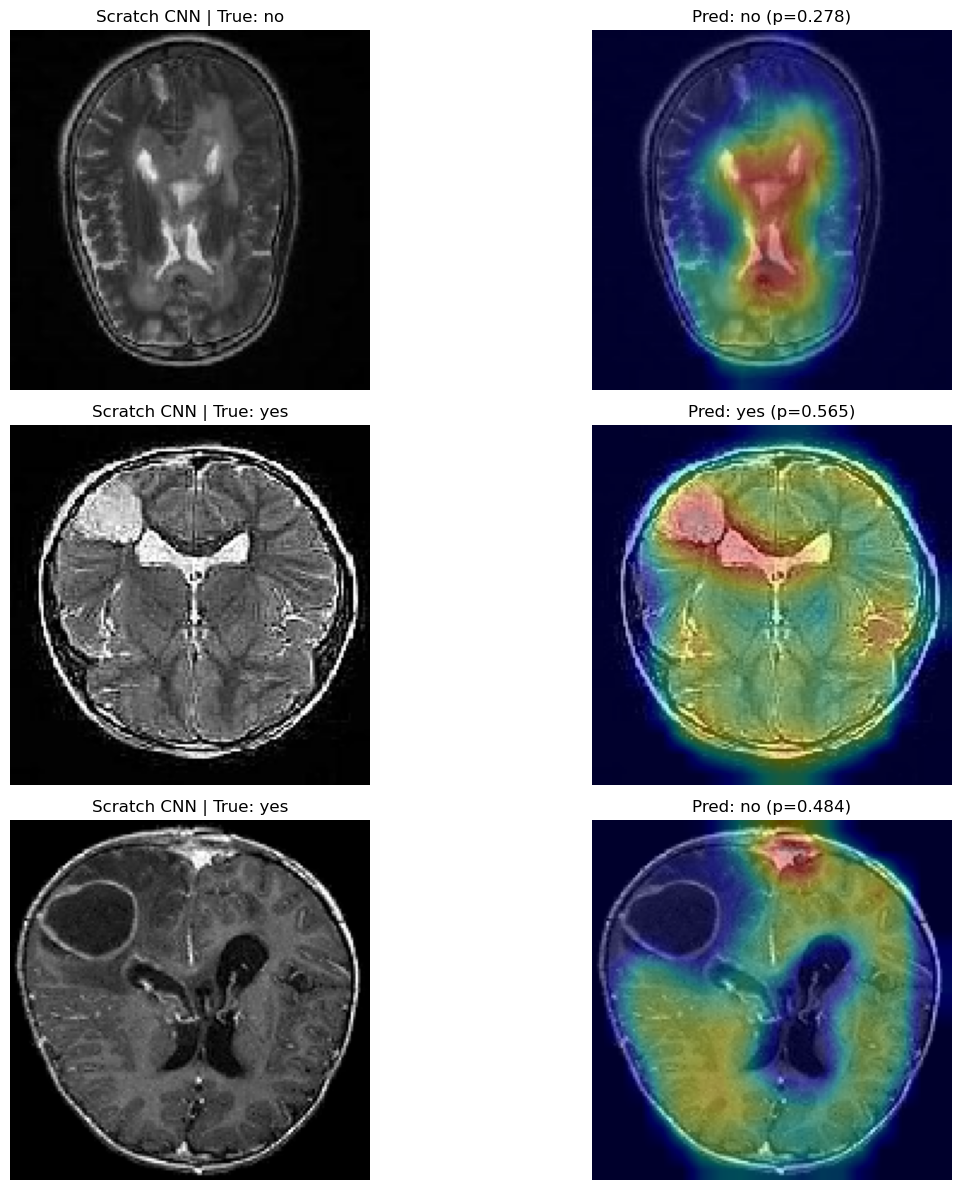

✅ ResNet50 TL | backbone=resnet50 | last4D=conv5_block3_out


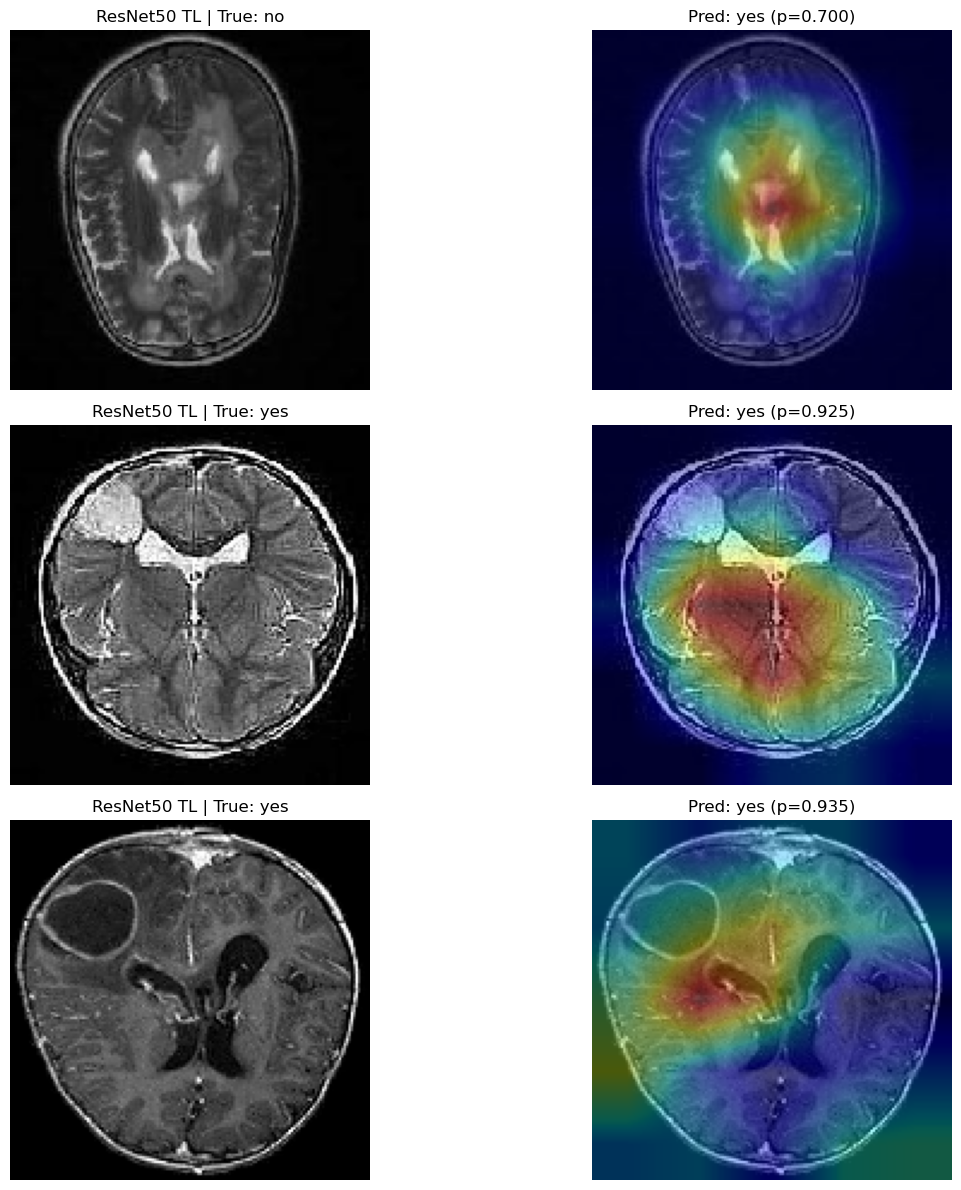

✅ DenseNet121 TL | backbone=densenet121 | last4D=relu


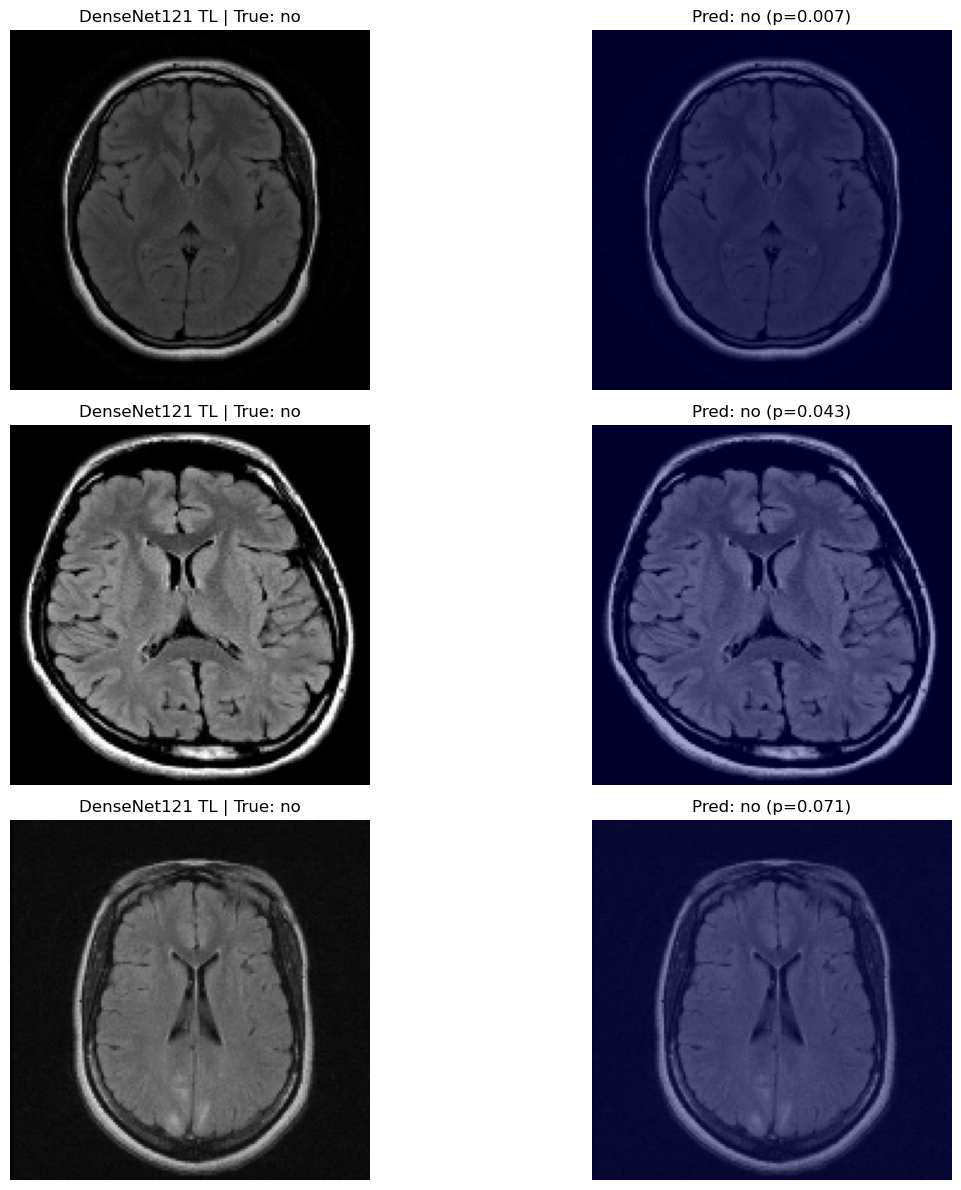

In [87]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# 0) Görüntüyü ekrana düzgün basmak için "deprocess"
# ============================================================
def deprocess_for_display(img, mode="none"):
    """
    mode:
      - "none": img zaten normal (0-1 veya 0-255)
      - "resnet_caffe": ResNet preprocess_input (BGR + mean subtraction)
      - "torch": (x-mean)/std normalize edilmiş RGB (DenseNet pipeline'larında sık)
    """
    x = img.astype(np.float32).copy()

    if mode == "resnet_caffe":
        x[..., 0] += 103.939
        x[..., 1] += 116.779
        x[..., 2] += 123.68
        x = x[..., ::-1]  # BGR -> RGB
        x = np.clip(x, 0, 255)

    elif mode == "torch":
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        x = (x * std + mean) * 255.0
        x = np.clip(x, 0, 255)

    else:
        if x.max() <= 1.0:
            x = x * 255.0
        x = np.clip(x, 0, 255)

    return x.astype(np.uint8)


def overlay_heatmap_fixed(img, heatmap, alpha=0.35, mode="none", cmap_name="jet"):
    base = deprocess_for_display(img, mode=mode)

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (base.shape[0], base.shape[1])
    ).numpy().squeeze()

    cmap = plt.get_cmap(cmap_name)
    colored = cmap(heatmap_resized)[:, :, :3]
    colored = (colored * 255).astype(np.uint8)

    overlay = (1 - alpha) * base + alpha * colored
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return base, overlay


def get_y_true(y_batch):
    if y_batch.ndim > 1 and y_batch.shape[-1] > 1:
        return np.argmax(y_batch, axis=1)
    return y_batch.astype(int).reshape(-1)


def get_last_4d_layer_name(model):
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except:
            pass
    raise ValueError("4D output layer (conv feature map) bulunamadı.")


# ============================================================
# 1) Grad-CAM – heatmap (Binary)
# ============================================================
def make_gradcam_heatmap_binary(img_array, grad_model):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor)   # preds: (1,1)
        class_channel = preds[:, 0]                    # pozitif sınıf (yes) skoru

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    prob = float(preds.numpy()[0, 0])
    pred_label = 1 if prob >= 0.5 else 0
    return heatmap.numpy(), prob, pred_label


# ============================================================
# 2) Scratch Grad-CAM modeli
# ============================================================
def build_gradcam_model_scratch(full_model, last_conv_name):
    conv_layer = full_model.get_layer(last_conv_name)
    return tf.keras.Model(
        inputs=full_model.inputs,
        outputs=[conv_layer.output, full_model.output]
    )


# ============================================================
# 3) TL (ResNet/DenseNet) Grad-CAM modeli
# ============================================================
def build_gradcam_model_tl_binary(full_model, backbone_name, last_conv_name,
                                  head_gap="head_gap", head_dense="head_dense",
                                  head_dropout="head_dropout", head_out="head_out"):
    backbone = full_model.get_layer(backbone_name)
    conv_layer = backbone.get_layer(last_conv_name)

    backbone_with_conv = tf.keras.Model(
        inputs=backbone.input,
        outputs=[conv_layer.output, backbone.output]
    )

    inputs = full_model.inputs
    conv_out, backbone_out = backbone_with_conv(inputs)

    x = full_model.get_layer(head_gap)(backbone_out)
    x = full_model.get_layer(head_dense)(x)
    x = full_model.get_layer(head_dropout)(x)
    preds = full_model.get_layer(head_out)(x)  # (B,1) sigmoid

    return tf.keras.Model(inputs=inputs, outputs=[conv_out, preds])


def get_last_4d_from_backbone(full_model, backbone_name):
    backbone = full_model.get_layer(backbone_name)
    return get_last_4d_layer_name(backbone)


# ============================================================
# 4) Gösterim (Scratch CNN) — 3 örnek
# ============================================================
def show_gradcam_binary_scratch(model, test_gen, title_prefix,
                               last_conv_name="last_conv", n_samples=3,
                               display_mode="none", cmap_name="jet"):

    grad_model = build_gradcam_model_scratch(model, last_conv_name)

    x_batch, y_batch = next(test_gen)
    y_true = get_y_true(y_batch)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

    n = min(n_samples, x_batch.shape[0])
    plt.figure(figsize=(14, 4*n))

    for i in range(n):
        img = x_batch[i]
        img_array = img[None, ...].astype("float32")

        heatmap, prob, pred_label = make_gradcam_heatmap_binary(img_array, grad_model)
        base, overlay = overlay_heatmap_fixed(img, heatmap, alpha=0.35,
                                              mode=display_mode, cmap_name=cmap_name)

        plt.subplot(n, 2, 2*i+1)
        plt.imshow(base)
        plt.axis("off")
        plt.title(f"{title_prefix} | True: {idx_to_class[int(y_true[i])]}")

        plt.subplot(n, 2, 2*i+2)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(f"Pred: {idx_to_class[pred_label]} (p={prob:.3f})")

    plt.tight_layout()
    plt.show()


# ============================================================
# 5) Gösterim (ResNet/DenseNet) — 3 örnek
# ============================================================
def show_gradcam_binary_tl(model, test_gen, title_prefix,
                          backbone_name, last_conv_name=None,
                          n_samples=3, display_mode="resnet_caffe",
                          cmap_name="jet"):

    if last_conv_name is None:
        last_conv_name = get_last_4d_from_backbone(model, backbone_name)

    print(f"✅ {title_prefix} | backbone={backbone_name} | last4D={last_conv_name}")

    grad_model = build_gradcam_model_tl_binary(
        full_model=model,
        backbone_name=backbone_name,
        last_conv_name=last_conv_name,
        head_gap="head_gap",
        head_dense="head_dense",
        head_dropout="head_dropout",
        head_out="head_out"
    )

    x_batch, y_batch = next(test_gen)
    y_true = get_y_true(y_batch)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

    n = min(n_samples, x_batch.shape[0])
    plt.figure(figsize=(14, 4*n))

    for i in range(n):
        img = x_batch[i]
        img_array = img[None, ...].astype("float32")

        heatmap, prob, pred_label = make_gradcam_heatmap_binary(img_array, grad_model)
        base, overlay = overlay_heatmap_fixed(img, heatmap, alpha=0.35,
                                              mode=display_mode, cmap_name=cmap_name)

        plt.subplot(n, 2, 2*i+1)
        plt.imshow(base)
        plt.axis("off")
        plt.title(f"{title_prefix} | True: {idx_to_class[int(y_true[i])]}")

        plt.subplot(n, 2, 2*i+2)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(f"Pred: {idx_to_class[pred_label]} (p={prob:.3f})")

    plt.tight_layout()
    plt.show()


# ============================================================
# 6) 3 MODEL — sadece 3 örnek
# ============================================================

show_gradcam_binary_scratch(
    model=scratch_model,
    test_gen=test_gen_scratch,
    title_prefix="Scratch CNN",
    last_conv_name="last_conv",
    n_samples=3,
    display_mode="none",
    cmap_name="jet"
)

show_gradcam_binary_tl(
    model=resnet_model,
    test_gen=test_gen_res,
    title_prefix="ResNet50 TL",
    backbone_name="resnet50",
    last_conv_name=None,
    n_samples=3,
    display_mode="resnet_caffe",
    cmap_name="jet"
)

show_gradcam_binary_tl(
    model=densenet_model,
    test_gen=test_gen_dn,
    title_prefix="DenseNet121 TL",
    backbone_name="densenet121",
    last_conv_name=None,
    n_samples=3,
    display_mode="torch",
    cmap_name="jet"
)
